# CIFAR-10 — Comparaison des optimiseurs
**EFREI Paris — Optimisation Convexe**

Comparaison de 5 optimiseurs : SGD, SGD+Momentum, AdaGrad, RMSProp, Adam

## 1. Imports

### Initialisation de l'environnement
Importe les bibliothèques nécessaires, détecte le périphérique de calcul disponible (`cuda` ou `cpu`) et affiche la version de PyTorch utilisée.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import wandb
import os

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# DEVICE = torch.device("mps")
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

PyTorch: 2.12.0+cu130
Device : cuda


### Notes de travail
Cellule de notes temporaires indiquant deux ajustements à prévoir : augmenter la taille du dataset pour le grid search et renommer le projet Weights & Biases.


## 2. Recherche d'hyperparamètres — Grid Search (Learning Rate)
Pour assurer que les optimiseurs ont egal sur le point depart, nous avons decide de chercher le meilleur learning rate pour chaque optimiseur.

Grid search du meilleur learning rate pour chaque optimiseur sur la plage **[1e-5, 1e-2]** (8 valeurs log-espacées).  
Chaque configuration est évaluée sur 2 époques avec un sous-ensemble de 5 000 images pour limiter le temps de calcul.

### Préparation des données pour le grid search
Charge CIFAR-10, applique une normalisation standard, sélectionne des sous-ensembles reproductibles pour l'entraînement et la validation, puis construit les `DataLoader` utilisés pendant la recherche d'hyperparamètres.


In [4]:
# ── Ensemble CIFAR-10 pour le grid search ───────────────────────────
_GS_SUBSET_TRAIN = 5_0000
_GS_SUBSET_VAL   = 1_0000
_GS_BATCH        = 128
_GS_EPOCHS       = 30
_GS_SEED         = 42

_gs_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

_full_train_gs = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=_gs_transform)
_full_val_gs   = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=_gs_transform)

torch.manual_seed(_GS_SEED)
_train_idx = torch.randperm(len(_full_train_gs))[:_GS_SUBSET_TRAIN].tolist()
_val_idx   = list(range(_GS_SUBSET_VAL))

_gs_trainloader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(_full_train_gs, _train_idx),
    batch_size=_GS_BATCH, shuffle=True, num_workers=2)
_gs_valloader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(_full_val_gs, _val_idx),
    batch_size=_GS_BATCH, shuffle=False, num_workers=2)

print(f"Grid search — train subset : {_GS_SUBSET_TRAIN:,} | val subset : {_GS_SUBSET_VAL:,}")

Grid search — train subset : 50,000 | val subset : 10,000


### Exécution du grid search
Définit un CNN de référence, teste plusieurs learning rates pour chaque optimiseur, entraîne chaque configuration, puis mesure la précision de validation obtenue.


In [5]:
# ── Architecture identique à SimpleCNN ───────────────────────────────────
class _GridCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        return self.net(x)

# ── Grid de learning rates : 8 valeurs log-espacées entre 1e-5 et 1e-2 ───
LR_GRID = np.logspace(-5, -2, 8)

_GS_OPTIMIZERS = [
    ("SGD",          optim.SGD,     {}),
    ("SGD+Momentum", optim.SGD,     {"momentum": 0.9}),
    ("AdaGrad",      optim.Adagrad, {}),
    ("RMSProp",      optim.RMSprop, {"alpha": 0.9}),
    ("Adam",         optim.Adam,    {"betas": (0.9, 0.999)}),
]

_criterion_gs = nn.CrossEntropyLoss()
gs_results    = {}

for _opt_name, _opt_cls, _extra_kw in _GS_OPTIMIZERS:
    gs_results[_opt_name] = {}
    print(f"\n{'─'*40}")
    print(f"  {_opt_name}")
    print(f"{'─'*40}")
    for lr in LR_GRID:
        torch.manual_seed(_GS_SEED)
        _model     = _GridCNN().to(DEVICE)
        _optimizer = _opt_cls(_model.parameters(), lr=float(lr), **_extra_kw)

        for _ in range(_GS_EPOCHS):
            _model.train()
            for _imgs, _lbls in _gs_trainloader:
                _imgs, _lbls = _imgs.to(DEVICE), _lbls.to(DEVICE)
                _optimizer.zero_grad()
                _criterion_gs(_model(_imgs), _lbls).backward()
                _optimizer.step()

        _model.eval()
        _correct = _total = 0
        with torch.no_grad():
            for _imgs, _lbls in _gs_valloader:
                _imgs, _lbls = _imgs.to(DEVICE), _lbls.to(DEVICE)
                _correct += (_model(_imgs).argmax(1) == _lbls).sum().item()
                _total   += _lbls.size(0)

        _val_acc = 100.0 * _correct / _total
        gs_results[_opt_name][float(lr)] = _val_acc
        print(f"  lr={lr:.2e}  →  val_acc={_val_acc:.1f}%")

print("\nGrid search terminé.")


────────────────────────────────────────
  SGD
────────────────────────────────────────
  lr=1.00e-05  →  val_acc=24.6%
  lr=2.68e-05  →  val_acc=34.2%
  lr=1.93e-04  →  val_acc=51.9%
  lr=5.18e-04  →  val_acc=63.9%
  lr=1.39e-03  →  val_acc=71.9%
  lr=3.73e-03  →  val_acc=74.5%
  lr=1.00e-02  →  val_acc=77.8%

────────────────────────────────────────
  SGD+Momentum
────────────────────────────────────────
  lr=1.00e-05  →  val_acc=44.7%
  lr=2.68e-05  →  val_acc=55.9%
  lr=7.20e-05  →  val_acc=67.5%
  lr=1.93e-04  →  val_acc=74.4%
  lr=5.18e-04  →  val_acc=75.2%
  lr=3.73e-03  →  val_acc=81.4%
  lr=1.00e-02  →  val_acc=84.1%

────────────────────────────────────────
  AdaGrad
────────────────────────────────────────
  lr=2.68e-05  →  val_acc=45.9%
  lr=1.93e-04  →  val_acc=64.2%
  lr=5.18e-04  →  val_acc=70.7%
  lr=1.39e-03  →  val_acc=74.9%
  lr=3.73e-03  →  val_acc=78.2%
  lr=1.00e-02  →  val_acc=80.7%

────────────────────────────────────────
  RMSProp
────────────────────────────

### Analyse des meilleurs learning rates
Construit un tableau récapitulatif des meilleurs learning rates, trace les courbes de précision en fonction du learning rate et sauvegarde la figure dans `results/`.


,Meilleur LR,Val acc (%)
Optimiseur,,
SGD,1.00e-02,77.85
SGD+Momentum,1.00e-02,84.07
AdaGrad,1.00e-02,80.69
RMSProp,1.39e-03,80.23
Adam,1.39e-03,81.83



Meilleurs LR : {'SGD': '1.00e-02', 'SGD+Momentum': '1.00e-02', 'AdaGrad': '1.00e-02', 'RMSProp': '1.39e-03', 'Adam': '1.39e-03'}


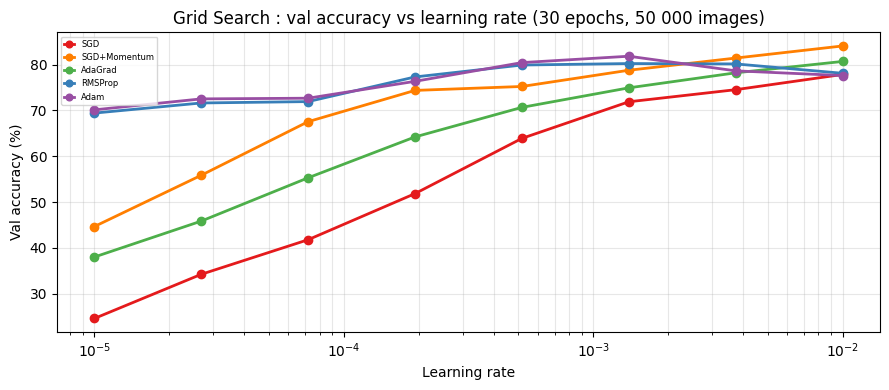

In [14]:
# ── Tableau des meilleurs LR + courbe val acc vs LR ──────────────────────
best_lr_per_opt = {}
_gs_rows = []
for _opt_name, _lr_accs in gs_results.items():
    _best_lr  = max(_lr_accs, key=_lr_accs.get)
    _best_acc = _lr_accs[_best_lr]
    best_lr_per_opt[_opt_name] = _best_lr
    _gs_rows.append({
        "Optimiseur":  _opt_name,
        "Meilleur LR": f"{_best_lr:.2e}",
        "Val acc (%)": f"{_best_acc:.2f}",
    })

_gs_df = pd.DataFrame(_gs_rows).set_index("Optimiseur")
display(_gs_df)
print("\nMeilleurs LR :", {k: f"{v:.2e}" for k, v in best_lr_per_opt.items()})

# ── Courbes ───────────────────────────────────────────────────────────────
_gs_colors = {
    "SGD":          "#e41a1c",
    "SGD+Momentum": "#ff7f00",
    "AdaGrad":      "#4daf4a",
    "RMSProp":      "#377eb8",
    "Adam":         "#984ea3",
}

fig, ax = plt.subplots(figsize=(9, 4))
for _opt_name, _lr_accs in gs_results.items():
    _lrs  = sorted(_lr_accs.keys())
    _accs = [_lr_accs[lr] for lr in _lrs]
    ax.semilogx(_lrs, _accs, marker='o', label=_opt_name,
                color=_gs_colors.get(_opt_name), linewidth=2)

ax.set_xlabel("Learning rate")
ax.set_ylabel("Val accuracy (%)")
ax.set_title("Grid Search : val accuracy vs learning rate (30 epochs, 50 000 images)")
ax.legend(loc="upper left", fontsize=6, markerscale=0.8, handlelength=1.2, borderpad=0.4)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/gs_lr_search.png", dpi=150)
plt.show()

## 3. Configuration

### Paramètres globaux de l'expérience
Fixe la graine aléatoire, le nombre d'époques, la taille des batchs, la liste des optimiseurs comparés et les couleurs utilisées pour les visualisations.


In [8]:
SEED       = 42
NUM_EPOCHS = 30
BATCH_SIZE = 128

torch.manual_seed(SEED)
np.random.seed(SEED)

os.makedirs("results", exist_ok=True)

# (name, optimizer class, kwargs)
OPTIMIZERS = [
    ("SGD",          optim.SGD,     {"lr": 0.01}),
    ("SGD+Momentum", optim.SGD,     {"lr": 0.01, "momentum": 0.9}),
    ("AdaGrad",      optim.Adagrad, {"lr": 0.01}),
    ("RMSProp",      optim.RMSprop, {"lr": 0.001, "alpha": 0.9}),
    ("Adam",         optim.Adam,    {"lr": 0.001, "betas": (0.9, 0.999)}),
    ("Muon",         optim.Muon,    {"lr": 0.001})
]

COLORS = {
    "SGD": "#e41a1c",
    "SGD+Momentum": "#ff7f00",
    "AdaGrad": "#4daf4a",
    "RMSProp": "#377eb8",
    "Adam": "#984ea3",
    "Muon": "#3cb44b",
}

print("Config OK")

Config OK


## 4. Données CIFAR-10

### Chargement des données CIFAR-10
Définit les transformations d'entraînement et de test, télécharge les jeux de données CIFAR-10, puis crée les `DataLoader` principaux pour l'entraînement final.


In [9]:
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train : {len(trainset):,} images")
print(f"Test  : {len(testset):,} images")

Train : 50,000 images
Test  : 10,000 images


## 5. Architecture CNN

### Simple image classification

### Définition du modèle CNN
Crée l'architecture `SimpleCNN` utilisée pour toutes les expériences, vérifie rapidement la forme de sortie et affiche le nombre de paramètres entraînables.


In [10]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # bloc 1 — 32x32
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 16x16
            # bloc 2 — 16x16
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 8x8
            # bloc 3 — 8x8
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 4x4
            # classifieur
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)


# vérification rapide
dummy = SimpleCNN().to(DEVICE)
out   = dummy(torch.randn(4, 3, 32, 32).to(DEVICE))
n_params = sum(p.numel() for p in dummy.parameters())
print(f"Output shape : {out.shape}  (attendu [4, 10])")
print(f"Paramètres   : {n_params:,}")
del dummy

Output shape : torch.Size([4, 10])  (attendu [4, 10])
Paramètres   : 667,178


## 6. Entraînement des 5 optimiseurs

Boucle d'entraînement inline, pas de fonctions intermédiaires.

### Entraînement et journalisation des optimiseurs
Entraîne le même CNN avec chaque optimiseur, calcule les métriques train/test, suit la norme des gradients, envoie les résultats à Weights & Biases et stocke les courbes dans `all_results`.


In [11]:
all_results = {}
criterion   = nn.CrossEntropyLoss()
epochs_list = list(range(1, NUM_EPOCHS + 1))

WANDB_PROJECT = "cifar10-optimizer-comparison"

for opt_name, opt_cls, opt_kwargs in OPTIMIZERS:
    print(f"\n{'='*50}")
    print(f"Optimiseur : {opt_name}  —  {opt_kwargs}")
    print(f"{'='*50}")

    torch.manual_seed(SEED)
    model     = SimpleCNN().to(DEVICE)
    optimizer = opt_cls(model.parameters(), **opt_kwargs)

    run = wandb.init(
        project=WANDB_PROJECT,
        name=opt_name,
        config={
            "optimizer":  opt_name,
            "lr":         opt_kwargs.get("lr"),
            "momentum":   opt_kwargs.get("momentum", None),
            "epochs":     NUM_EPOCHS,
            "batch_size": BATCH_SIZE,
            "seed":       SEED,
            **{k: v for k, v in opt_kwargs.items() if k not in ("lr", "momentum")},
        },
        reinit=True,
    )

    train_losses, train_accs = [], []
    test_losses,  test_accs  = [], []
    grad_norms = []
    global_step = 0

    # ── Step 0: évaluation avant tout entraînement ────────
    model.eval()
    run_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in trainloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            run_loss += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += images.size(0)
    init_train_loss = run_loss / total
    init_train_acc  = 100.0 * correct / total

    run_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            run_loss += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += images.size(0)
    init_test_loss = run_loss / total
    init_test_acc  = 100.0 * correct / total

    # initial grad norm from one batch
    images, labels = next(iter(trainloader))
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    optimizer.zero_grad()
    criterion(model(images), labels).backward()
    init_grad_norm = sum(p.grad.norm().item() ** 2
                         for p in model.parameters() if p.grad is not None) ** 0.5
    optimizer.zero_grad()

    wandb.log({
        "train/batch_loss": init_train_loss,
        "train/loss":       init_train_loss,
        "train/accuracy":   init_train_acc,
        "test/loss":        init_test_loss,
        "test/accuracy":    init_test_acc,
        "grad_norm":        init_grad_norm,
        "gen_gap":          init_train_acc - init_test_acc,
    }, step=0)

    for epoch in epochs_list:

        # ── Entraînement ──────────────────────────────────
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        batch_grad_norms = []

        for images, labels in trainloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()

            g = sum(p.grad.norm().item() ** 2
                    for p in model.parameters() if p.grad is not None) ** 0.5
            batch_grad_norms.append(g)

            optimizer.step()
            global_step += 1

            run_loss += loss.item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += images.size(0)

            # log batch loss every 10 batches
            if global_step % 10 == 0:
                wandb.log({"train/batch_loss": loss.item(), "grad_norm": g}, step=global_step)

        train_losses.append(run_loss / total)
        train_accs.append(100.0 * correct / total)
        grad_norms.append(float(np.mean(batch_grad_norms)))

        # ── Évaluation test ───────────────────────────────
        model.eval()
        run_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                run_loss += criterion(outputs, labels).item() * images.size(0)
                correct  += (outputs.argmax(1) == labels).sum().item()
                total    += images.size(0)

        test_losses.append(run_loss / total)
        test_accs.append(100.0 * correct / total)

        # log epoch-level metrics
        wandb.log({
            "train/loss":      train_losses[-1],
            "train/accuracy":  train_accs[-1],
            "test/loss":       test_losses[-1],
            "test/accuracy":   test_accs[-1],
            "gen_gap":         train_accs[-1] - test_accs[-1],
        }, step=global_step)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>2}/{NUM_EPOCHS} "
                  f"| train {train_accs[-1]:.1f}% "
                  f"| test  {test_accs[-1]:.1f}%")

    wandb.summary["best_test_accuracy"]    = max(test_accs)
    wandb.summary["final_train_accuracy"]  = train_accs[-1]
    wandb.summary["final_gen_gap"]         = train_accs[-1] - test_accs[-1]

    run.finish()

    all_results[opt_name] = {
        "train_loss": train_losses,
        "train_acc":  train_accs,
        "test_loss":  test_losses,
        "test_acc":   test_accs,
        "grad_norm":  grad_norms,
    }
    print(f"  → Meilleure précision test : {max(test_accs):.2f}%")

print("\nToutes les expériences terminées.")


Optimiseur : SGD  —  {'lr': 0.01}


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: thophamkw (thophamkw-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  Epoch  1/30 | train 39.4% | test  50.1%
  Epoch  5/30 | train 66.6% | test  70.4%
  Epoch 10/30 | train 74.1% | test  74.8%
  Epoch 15/30 | train 78.2% | test  76.7%
  Epoch 20/30 | train 80.9% | test  80.2%
  Epoch 25/30 | train 82.4% | test  79.9%
  Epoch 30/30 | train 84.0% | test  81.8%


gen_gap,▆▁▃▃▄▄▇▅▆▇▅▇▆▇▆▆▇▆▇█▆▆▆▇▇▇▇██▇▇
grad_norm,▃▁▄▇▃▅▄▆▄▆▅▅▆▇▄▂▅▆▇▄▅▆▃▃▂▃▂▆▃▅▆▂▆▁█▄▄▃▃▃
test/accuracy,▁▅▆▆▇▇▇▇▇▇▇▇▇▇█▇▇██▇███████████
test/loss,█▄▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▂▁▁▁▂▁▁▁
train/accuracy,▁▄▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████████████
train/batch_loss,█▇▇▆▅▃▄▄▃▄▄▃▃▄▄▃▃▂▄▂▃▂▂▃▂▂▃▂▁▂▁▁▂▂▂▂▂▂▂▁
train/loss,█▆▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
best_test_accuracy,81.79
final_gen_gap,2.21
final_train_accuracy,84
gen_gap,2.21


  → Meilleure précision test : 81.79%

Optimiseur : SGD+Momentum  —  {'lr': 0.01, 'momentum': 0.9}


...

  → Meilleure précision test : 85.21%

Optimiseur : Adam  —  {'lr': 0.001, 'betas': (0.9, 0.999)}


  Epoch  1/30 | train 50.2% | test  61.3%
  Epoch  5/30 | train 77.8% | test  75.5%
  Epoch 10/30 | train 83.3% | test  82.3%
  Epoch 15/30 | train 86.2% | test  83.1%
  Epoch 20/30 | train 88.1% | test  84.0%
  Epoch 25/30 | train 89.3% | test  85.4%
  Epoch 30/30 | train 90.5% | test  85.9%


gen_gap,▆▁▄▅▆▇▇▆▆█▆▇▇▇▇▇▇█▇██▇▇▇▇█▇████
grad_norm,▅▆▅▅▅▆▄█▅▄▄▃▃▅▄▂▆▃▃▄▃▄▅▃▄▄▃▃▅▃▃▄▂▁▃▃▂▅▃▂
test/accuracy,▁▆▇▇▇▇▇▇█▇█▇███████████████████
test/loss,█▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▄▆▆▇▇▇▇▇▇▇▇▇██████████████████
train/batch_loss,██▄▃▃▃▃▃▃▃▂▃▃▂▂▂▂▂▂▂▂▃▂▂▂▂▂▁▁▂▂▂▂▁▁▂▂▂▂▁
train/loss,█▅▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_test_accuracy,86.76
final_gen_gap,4.636
final_train_accuracy,90.496
gen_gap,4.636


  → Meilleure précision test : 86.76%

Optimiseur : Muon  —  {'lr': 0.001}


ValueError: Muon only supports 2D parameters whereas we found a parameter with size: torch.Size([32, 3, 3, 3])

### Cellule libre
Cellule actuellement vide, conservée comme espace de travail pour ajouter des analyses ou visualisations complémentaires.


## 7. Tableau récapitulatif

### Synthèse des performances
Construit un tableau final avec la précision d'entraînement, la meilleure précision test, l'écart de généralisation et le nombre d'époques nécessaires pour atteindre 80 %, puis sauvegarde ce résumé en CSV.


In [12]:
rows = []
for name, res in all_results.items():
    gap  = res["train_acc"][-1] - res["test_acc"][-1]
    ep80 = next((i + 1 for i, a in enumerate(res["test_acc"]) if a >= 80), None)
    rows.append({
        "Optimiseur":          name,
        "Train acc (%)": f"{res['train_acc'][-1]:.2f}",
        "Test acc (%)":  f"{max(res['test_acc']):.2f}",
        "Gap génér. (%)": f"{gap:.2f}",
        "Epochs → 80%":  ep80 if ep80 else f">{NUM_EPOCHS}",
    })

df = pd.DataFrame(rows).set_index("Optimiseur")
display(df)

df.to_csv("results/summary_table.csv")
print("Sauvegardé : results/summary_table.csv")

,Train acc (%),Test acc (%),Gap génér. (%),Epochs → 80%
Optimiseur,,,,
SGD,84.00,81.79,2.21,20
SGD+Momentum,91.05,87.24,3.81,9
AdaGrad,84.91,83.31,1.60,16
RMSProp,90.24,85.21,5.12,10
Adam,90.50,86.76,4.64,7


Sauvegardé : results/summary_table.csv
